# 🎾 Padel Analytics — Étape 4 : Clustering
## Partie E — Segmentation des Joueurs de Padel

|---|---|
| **Objectif** | Regrouper les joueurs en **profils homogènes** selon leur niveau, classement et pays |
| **Modèles** | K-Means · DBSCAN |
| **Évaluation** | Silhouette Score · Davies-Bouldin Index · Elbow Method |

---
## 📚 1. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
print('✅ Imports OK')

✅ Imports OK


---
## 🔌 2. Chargement des données

In [10]:
engine = create_engine('mysql+mysqlconnector://root:@127.0.0.1:3306/dw_padel_analytics')

dim_player  = pd.read_sql('SELECT * FROM dim_player_ofc',  engine)
dim_country = pd.read_sql('SELECT * FROM dim_countryy',    engine)
fact_perf   = pd.read_sql('SELECT * FROM fact_performance', engine)

print(f'dim_player_ofc  : {dim_player.shape}')
display(dim_player.head(5))

dim_player_ofc  : (4118, 8)


,Name,Points,Position,Move,Genre,Id_Country,Id_Player,Level
0,ARTURO COELLO,19800.0,1.0,0.0,Male,1685,2522,Professional
1,AGUSTIN TAPIA,19800.0,1.0,0.0,Male,1686,2523,Professional
2,ALEJANDRO GALAN,17320.0,3.0,0.0,Male,1685,2524,Professional
3,FEDERICO CHINGOTTO,17320.0,3.0,0.0,Male,1686,2525,Professional
4,FRANCO STUPACZUK,7905.0,5.0,0.0,Male,1686,2526,Professional


---
## 🏗️ 3. Construction du Dataset Joueur

In [12]:
# Calcul du nombre de victoires par joueur
wins1 = fact_perf.groupby('Id_Player_1_winner').size().reset_index(name='wins_p1')
wins2 = fact_perf.groupby('Id_Player_2_winner').size().reset_index(name='wins_p2')
wins1.rename(columns={'Id_Player_1_winner':'Id_Player'}, inplace=True)
wins2.rename(columns={'Id_Player_2_winner':'Id_Player'}, inplace=True)
total_wins = pd.merge(wins1, wins2, on='Id_Player', how='outer').fillna(0)
total_wins['total_wins'] = total_wins['wins_p1'] + total_wins['wins_p2']

# Calcul du nombre de défaites
loss1 = fact_perf.groupby('Id_Player_1_loser').size().reset_index(name='loss_p1')
loss2 = fact_perf.groupby('Id_Player_2_loser').size().reset_index(name='loss_p2')
loss1.rename(columns={'Id_Player_1_loser':'Id_Player'}, inplace=True)
loss2.rename(columns={'Id_Player_2_loser':'Id_Player'}, inplace=True)
total_loss = pd.merge(loss1, loss2, on='Id_Player', how='outer').fillna(0)
total_loss['total_loss'] = total_loss['loss_p1'] + total_loss['loss_p2']

# Merge avec dim_player
player_df = dim_player.merge(total_wins[['Id_Player','total_wins']], on='Id_Player', how='left')
player_df = player_df.merge(total_loss[['Id_Player','total_loss']], on='Id_Player', how='left')
player_df['total_wins']  = player_df['total_wins'].fillna(0)
player_df['total_loss']  = player_df['total_loss'].fillna(0)
player_df['total_matchs'] = player_df['total_wins'] + player_df['total_loss']
player_df['win_rate']    = np.where(
    player_df['total_matchs'] > 0,
    player_df['total_wins'] / player_df['total_matchs'], 0
)

# Merge pays
player_df = player_df.merge(dim_country, on='Id_Country', how='left')

print(f'Dataset joueur : {player_df.shape}')
display(player_df[['Name','Points','Position','Level','total_wins','total_loss','win_rate','Country']].head(10))

Dataset joueur : (4118, 13)


,Name,Points,Position,Level,total_wins,total_loss,win_rate,Country
0,ARTURO COELLO,19800.0,1.0,Professional,0.0,0.0,0.000000,ESP
1,AGUSTIN TAPIA,19800.0,1.0,Professional,0.0,0.0,0.000000,ARG
2,ALEJANDRO GALAN,17320.0,3.0,Professional,3.0,1.0,0.750000,ESP
3,FEDERICO CHINGOTTO,17320.0,3.0,Professional,7.0,1.0,0.875000,ARG
4,FRANCO STUPACZUK,7905.0,5.0,Professional,20.0,1.0,0.952381,ARG
5,JUAN LEBRON,7845.0,6.0,Professional,13.0,2.0,0.866667,ESP
6,JORGE NIETO,6322.0,7.0,Professional,10.0,2.0,0.833333,ESP
7,MIGUEL YANGUAS,6322.0,7.0,Professional,25.0,3.0,0.892857,ESP
8,FRANCISCO NAVARRO,6115.0,9.0,Professional,26.0,3.0,0.896552,ESP
9,LEANDRO AUGSBURGER,5155.0,10.0,Professional,15.0,6.0,0.714286,ARG


In [13]:
# Features pour le clustering
cluster_features = ['Points', 'Position', 'Move', 'total_wins', 'total_loss',
                    'total_matchs', 'win_rate', 'Level', 'Genre']
cluster_features = [f for f in cluster_features if f in player_df.columns]

X_clust = player_df[cluster_features].copy()

# Encodage
le = LabelEncoder()
for col in X_clust.select_dtypes(include='object').columns:
    X_clust[col] = le.fit_transform(X_clust[col].astype(str))

# Imputation
imputer = SimpleImputer(strategy='median')
X_clust = pd.DataFrame(imputer.fit_transform(X_clust), columns=X_clust.columns)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f'✅ Dataset clustering : {X_scaled.shape}')

✅ Dataset clustering : (4118, 9)


---
## 🧠 E — Compréhension des Modèles

### K-Means
**Intuition :** Partitionne les données en **K clusters** en minimisant la distance intra-cluster. Chaque point appartient au centroïde le plus proche.  
**Algorithme :** Initialisation → Assignation → Mise à jour des centroïdes → Répétition jusqu'à convergence.  
**Paramètres :** `n_clusters` (K), `init`, `n_init`, `max_iter`.  
**Hypothèses :** Clusters sphériques et de taille similaire.  
**Limites :** Sensible aux outliers, nécessite de choisir K a priori.  
**Justification :** Idéal pour segmenter les joueurs en profils distincts (élite, intermédiaire, débutant).

### DBSCAN
**Intuition :** Identifie des clusters comme des **régions denses** séparées par des zones peu denses. Détecte les outliers (points de bruit).  
**Paramètres :** `eps` (rayon du voisinage), `min_samples` (min. de points pour former un cluster).  
**Hypothèses :** Clusters de forme arbitraire, densité variable.  
**Limites :** Difficile à calibrer, mauvais sur des données de haute dimension.  
**Justification :** Permet d'identifier des joueurs atypiques (outliers) — par ex. des joueurs très bien classés mais avec peu de matchs.

---
## 📐 E.1 — Méthode du Coude (Elbow) pour K-Means

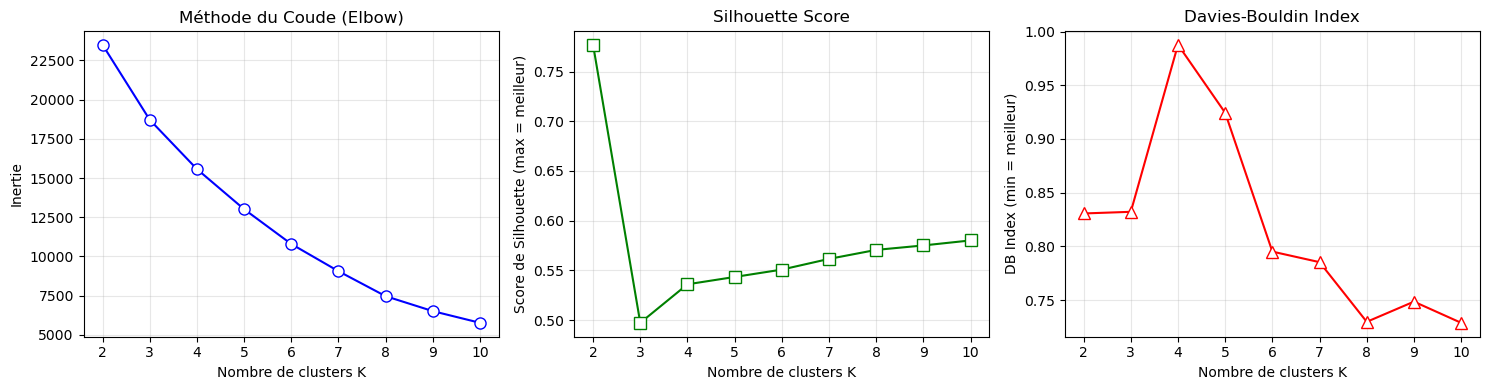


✅ K optimal selon Silhouette Score : K = 2


In [16]:
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'bo-', markerfacecolor='white', markersize=8)
axes[0].set_title('Méthode du Coude (Elbow)', fontsize=12)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, 'gs-', markerfacecolor='white', markersize=8)
axes[1].set_title('Silhouette Score', fontsize=12)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de Silhouette (max = meilleur)')
axes[1].grid(alpha=0.3)

axes[2].plot(K_range, db_scores, 'r^-', markerfacecolor='white', markersize=8)
axes[2].set_title('Davies-Bouldin Index', fontsize=12)
axes[2].set_xlabel('Nombre de clusters K')
axes[2].set_ylabel('DB Index (min = meilleur)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f'\n✅ K optimal selon Silhouette Score : K = {best_k}')

## 🔵 E.2 — K-Means avec K optimal

In [18]:
K_OPTIMAL = best_k  # ou forcer manuellement : K_OPTIMAL = 3

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

player_df['cluster_kmeans'] = km_labels

sil_km = silhouette_score(X_scaled, km_labels)
db_km  = davies_bouldin_score(X_scaled, km_labels)

print(f'K-Means (K={K_OPTIMAL})')
print(f'  Silhouette Score     : {sil_km:.4f}')
print(f'  Davies-Bouldin Index : {db_km:.4f}')
print(f'\nDistribution des clusters :')
print(player_df['cluster_kmeans'].value_counts().sort_index())

K-Means (K=2)
  Silhouette Score     : 0.7769
  Davies-Bouldin Index : 0.8306

Distribution des clusters :
cluster_kmeans
0    3955
1     163
Name: count, dtype: int64


## 🔴 E.3 — DBSCAN

In [20]:
# Tester plusieurs combinaisons eps / min_samples
from itertools import product

best_sil_db, best_eps, best_ms = -1, None, None
eps_vals = [0.3, 0.5, 0.8, 1.0, 1.5]
ms_vals  = [3, 5, 10]

print('DBSCAN — recherche des meilleurs hyperparamètres :')
for eps, ms in product(eps_vals, ms_vals):
    db_model = DBSCAN(eps=eps, min_samples=ms)
    labels   = db_model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)
    if n_clusters >= 2 and n_noise < len(labels) * 0.5:
        mask = labels != -1
        sil  = silhouette_score(X_scaled[mask], labels[mask])
        print(f'  eps={eps}, min_samples={ms} → {n_clusters} clusters, {n_noise} bruit, Sil={sil:.3f}')
        if sil > best_sil_db:
            best_sil_db, best_eps, best_ms = sil, eps, ms

print(f'\n✅ Meilleurs params DBSCAN : eps={best_eps}, min_samples={best_ms}, Sil={best_sil_db:.4f}')

DBSCAN — recherche des meilleurs hyperparamètres :
  eps=0.3, min_samples=3 → 40 clusters, 313 bruit, Sil=0.374
  eps=0.3, min_samples=5 → 22 clusters, 377 bruit, Sil=0.398
  eps=0.3, min_samples=10 → 11 clusters, 470 bruit, Sil=0.397
  eps=0.5, min_samples=3 → 40 clusters, 271 bruit, Sil=0.435
  eps=0.5, min_samples=5 → 21 clusters, 341 bruit, Sil=0.434
  eps=0.5, min_samples=10 → 14 clusters, 399 bruit, Sil=0.434
  eps=0.8, min_samples=3 → 34 clusters, 209 bruit, Sil=0.603
  eps=0.8, min_samples=5 → 18 clusters, 271 bruit, Sil=0.602
  eps=0.8, min_samples=10 → 9 clusters, 334 bruit, Sil=0.605
  eps=1.0, min_samples=3 → 32 clusters, 153 bruit, Sil=0.590
  eps=1.0, min_samples=5 → 20 clusters, 208 bruit, Sil=0.593
  eps=1.0, min_samples=10 → 10 clusters, 289 bruit, Sil=0.600
  eps=1.5, min_samples=3 → 19 clusters, 88 bruit, Sil=0.579
  eps=1.5, min_samples=5 → 13 clusters, 127 bruit, Sil=0.584
  eps=1.5, min_samples=10 → 7 clusters, 214 bruit, Sil=0.592

✅ Meilleurs params DBSCAN : eps

In [21]:
dbscan = DBSCAN(eps=best_eps if best_eps else 0.8, min_samples=best_ms if best_ms else 5)
db_labels = dbscan.fit_predict(X_scaled)

player_df['cluster_dbscan'] = db_labels

n_clust_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

mask = db_labels != -1
if mask.sum() > 1 and n_clust_db >= 2:
    sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
    db_db  = davies_bouldin_score(X_scaled[mask], db_labels[mask])
else:
    sil_db, db_db = 0, 0

print(f'DBSCAN — {n_clust_db} clusters, {n_noise_db} points de bruit')
print(f'  Silhouette Score     : {sil_db:.4f}')
print(f'  Davies-Bouldin Index : {db_db:.4f}')

DBSCAN — 9 clusters, 334 points de bruit
  Silhouette Score     : 0.6049
  Davies-Bouldin Index : 0.5824


## 📊 E.4 — Comparaison K-Means vs DBSCAN

In [24]:
comp_clust = pd.DataFrame({
    'Modèle'              : ['K-Means', 'DBSCAN'],
    'Nb Clusters'         : [K_OPTIMAL, n_clust_db],
    'Silhouette Score'    : [round(sil_km, 4), round(sil_db, 4)],
    'Davies-Bouldin Index': [round(db_km, 4),  round(db_db, 4)],
    'Points de Bruit'     : [0, n_noise_db]
}).set_index('Modèle')

print('📊 COMPARAISON CLUSTERING')
display(comp_clust)

📊 COMPARAISON CLUSTERING


,Nb Clusters,Silhouette Score,Davies-Bouldin Index,Points de Bruit
Modèle,,,,
K-Means,2,0.7769,0.8306,0
DBSCAN,9,0.6049,0.5824,334


## 🗺️ E.5 — Visualisation PCA 2D

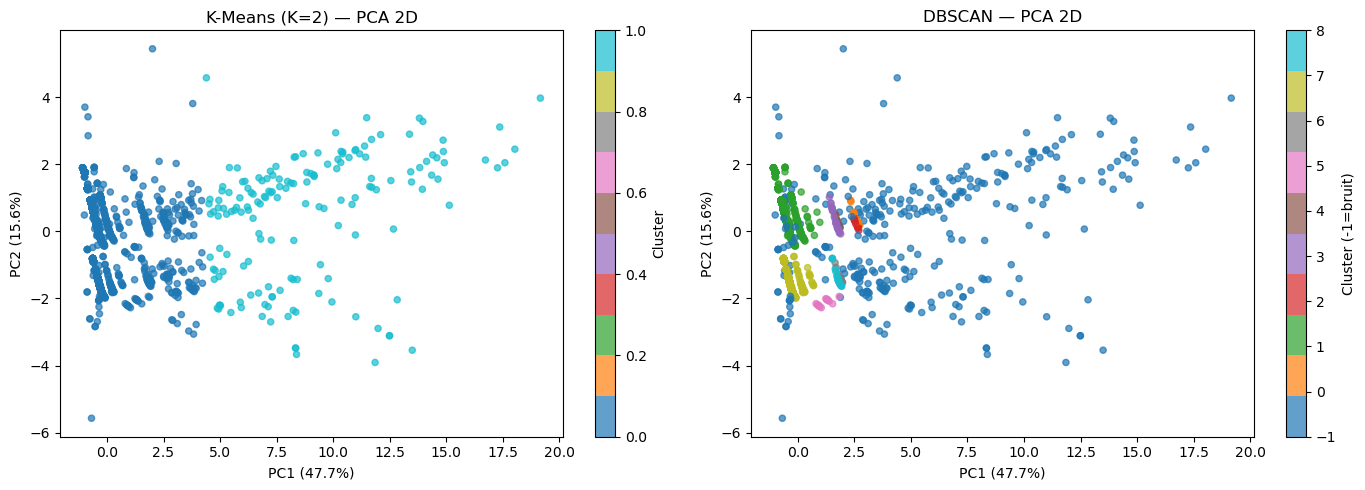


Variance expliquée par les 2 composantes PCA : 63.3%


In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=km_labels, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title(f'K-Means (K={K_OPTIMAL}) — PCA 2D', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN PCA
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=db_labels, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('DBSCAN — PCA 2D', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=bruit)')

plt.tight_layout()
plt.show()

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'\nVariance expliquée par les 2 composantes PCA : {var_explained:.1f}%')

## 📌 E.6 — Profiling des Clusters (K-Means)

📋 Profil moyen par cluster (K-Means) :


,Points,Position,total_wins,total_loss,win_rate
cluster_kmeans,,,,,
0,51.98,1101.16,0.09,0.15,0.03
1,2712.80,94.00,7.88,5.71,0.57


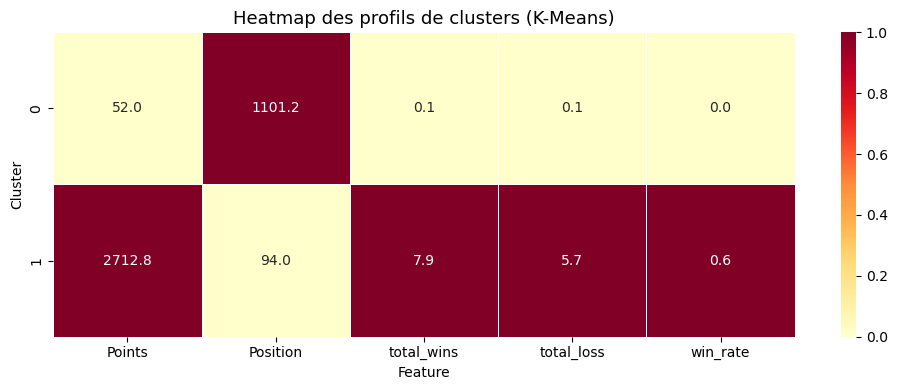

In [31]:
numeric_feats = ['Points', 'Position', 'total_wins', 'total_loss', 'win_rate']
numeric_feats = [f for f in numeric_feats if f in player_df.columns]

profile = player_df.groupby('cluster_kmeans')[numeric_feats].mean().round(2)
print('📋 Profil moyen par cluster (K-Means) :')
display(profile)

# Heatmap des profils
fig, ax = plt.subplots(figsize=(10, 4))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Heatmap des profils de clusters (K-Means)', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

In [32]:
# Interprétation des clusters
print('📌 Interprétation des clusters :')
for cluster_id in sorted(player_df['cluster_kmeans'].unique()):
    sub = player_df[player_df['cluster_kmeans'] == cluster_id]
    avg_pts = sub['Points'].mean() if 'Points' in sub else 0
    avg_wr  = sub['win_rate'].mean() if 'win_rate' in sub else 0
    n = len(sub)
    print(f'  Cluster {cluster_id} : {n} joueurs | Points moy. = {avg_pts:.0f} | Win rate = {avg_wr:.2%}')
    print(f'    Top 3 joueurs : {sub.nlargest(3,"Points")["Name"].tolist()}')

📌 Interprétation des clusters :
  Cluster 0 : 3955 joueurs | Points moy. = 52 | Win rate = 2.54%
    Top 3 joueurs : ['MARTINA CALVO SANTAMARIA', 'MARINA GUINART ESPAÑA', 'BEATRIZ CALDERA SANCHEZ']
  Cluster 1 : 163 joueurs | Points moy. = 2713 | Win rate = 56.74%
    Top 3 joueurs : ['ARTURO COELLO', 'AGUSTIN TAPIA', 'DELFINA BREA SENESI']
